INVERTER 32nm CMOS data

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando scalers
scaler_x = joblib.load('../data/processed/dados_32nm_cmos/scaler_x.pkl')
scaler_y = joblib.load('../data/processed/dados_32nm_cmos/scaler_y.pkl')

# Carregando os dados

X_train_sc = pd.read_csv('../data/processed/dados_32nm_cmos/X_train_sc.csv')
X_val_sc   = pd.read_csv('../data/processed/dados_32nm_cmos/X_val_sc.csv')
Xte_sc     = pd.read_csv('../data/processed/dados_32nm_cmos/X_test_sc.csv')

y_train_sc = pd.read_csv('../data/processed/dados_32nm_cmos/y_train_sc.csv')
y_val_sc   = pd.read_csv('../data/processed/dados_32nm_cmos/y_val_sc.csv')
yte_sc     = pd.read_csv('../data/processed/dados_32nm_cmos/y_test_sc.csv')

print(f"Training set loaded: {X_train_sc.shape}")
print(f"Validation set loaded: {X_val_sc.shape}")
print(f"Test set loaded: {Xte_sc.shape}")

Training set loaded: (64204, 7)
Validation set loaded: (31624, 7)
Test set loaded: (31943, 7)


# Multi-layer Perceptron (MPL)
Neural network for supervised learning

Idea:
- Single-output model approach (Predicting one output at a time)
- Multi-output model approach (Predicting three outputs at the same time)

Metrics
- R² score (coefficient of determination) regression score function
- RMSE and MSE error metrics

In [2]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.metrics import r2_score

In [3]:
scores = {}

In [4]:
def score(model, X, y, target_name, target_variable, target_set):
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = root_mean_squared_error(y, pred)
    mse = mean_squared_error(y, pred)

    scores[target_name, target_variable, target_set] = {
        'r2': r2,
        'rmse': rmse,
        'mse': mse,
    }
    return scores[target_name, target_variable, target_set]

## Multi-layer Perceptron for Regression using Scikit-Learn

In [5]:
from sklearn.neural_network import MLPRegressor

mlp_regressor= MLPRegressor(activation='relu',
                              solver = 'sgd',
                              hidden_layer_sizes=(100, ),
                              early_stopping = True,
                              random_state=42)

### Single-output models

#### Predicting TPHL

In [6]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['tphl'])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [7]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.002259759926010327


In [8]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [9]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['tphl'])

0.9955134553840366

In [10]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tphl'], y_pred_sc)
mse = mean_squared_error(y_val_sc['tphl'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.06709275871816466
clf: MLP, MSE 0.004501438272413859


In [11]:
score(mlp_regressor, X_val_sc, y_val_sc['tphl'], 'mlp_S_SKL', 'tphl', 'val')

{'r2': 0.9955134553840366,
 'rmse': 0.06709275871816466,
 'mse': 0.004501438272413859}

In [12]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [13]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['tphl'])

0.9954314294851766

In [14]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tphl'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['tphl'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.06802960956043218
clf: MLP, MSE 0.004628027776944846


In [15]:
score(mlp_regressor, Xte_sc, yte_sc['tphl'], 'mlp_S_SKL', 'tphl', 'test')

{'r2': 0.9954314294851766,
 'rmse': 0.06802960956043218,
 'mse': 0.004628027776944846}

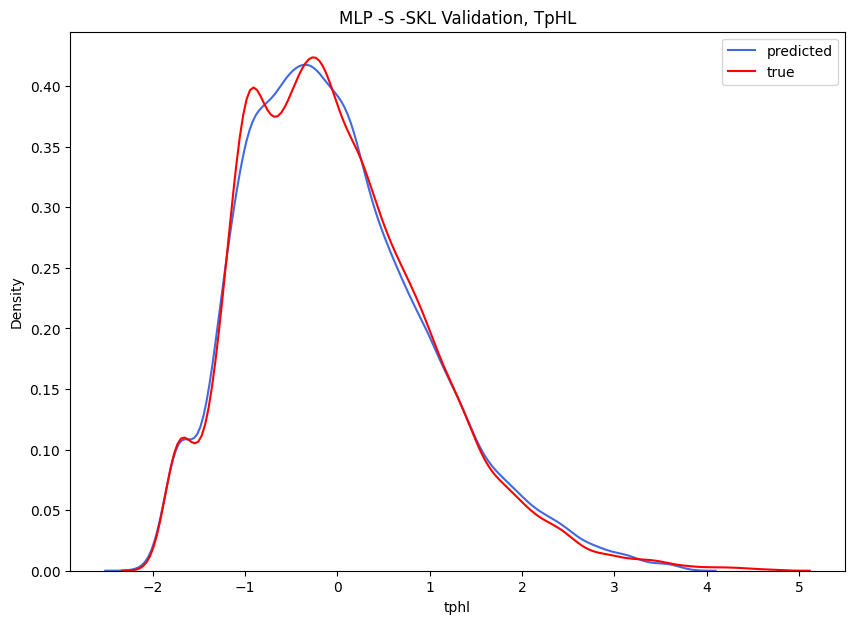

In [16]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpHL')
ax.legend()
plt.show()

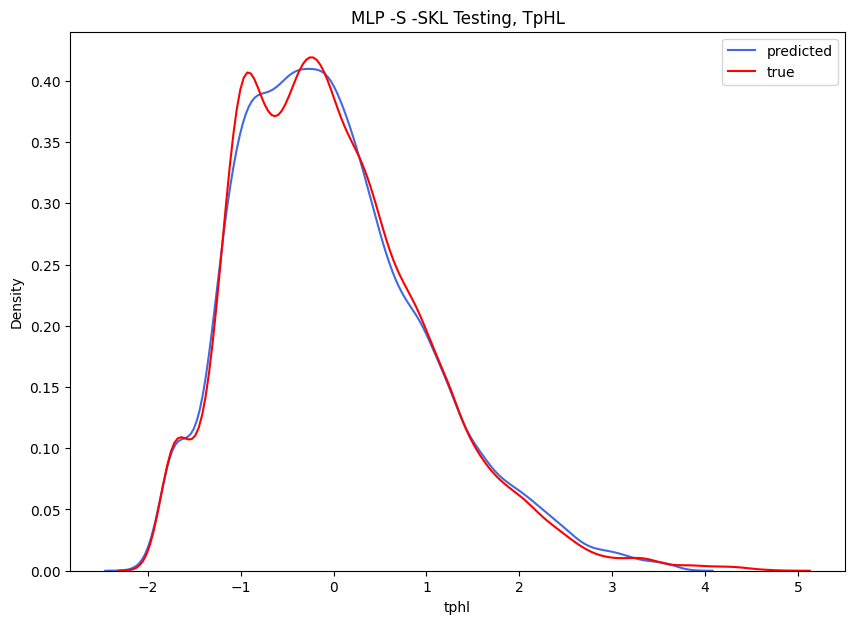

In [17]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpHL')
ax.legend()
plt.show()

#### Predicting TPLH

In [18]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['tplh'])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [19]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0020040750754831364


In [20]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [21]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['tplh'])

0.9961466654333807

In [22]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tplh'], y_pred_sc)
mse = mean_squared_error(y_val_sc['tplh'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.061260823449218786
clf: MLP, MSE 0.003752888489676354


In [23]:
score(mlp_regressor, X_val_sc, y_val_sc['tplh'], 'mlp_S_SKL', 'tplh', 'val')

{'r2': 0.9961466654333807,
 'rmse': 0.061260823449218786,
 'mse': 0.003752888489676354}

In [24]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [25]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['tplh'])

0.9960732060415697

In [26]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tplh'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['tplh'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.06257906870078851
clf: MLP, MSE 0.003916139839458008


In [27]:
score(mlp_regressor, Xte_sc, yte_sc['tplh'], 'mlp_S_SKL', 'tplh', 'test')

{'r2': 0.9960732060415697,
 'rmse': 0.06257906870078851,
 'mse': 0.003916139839458008}

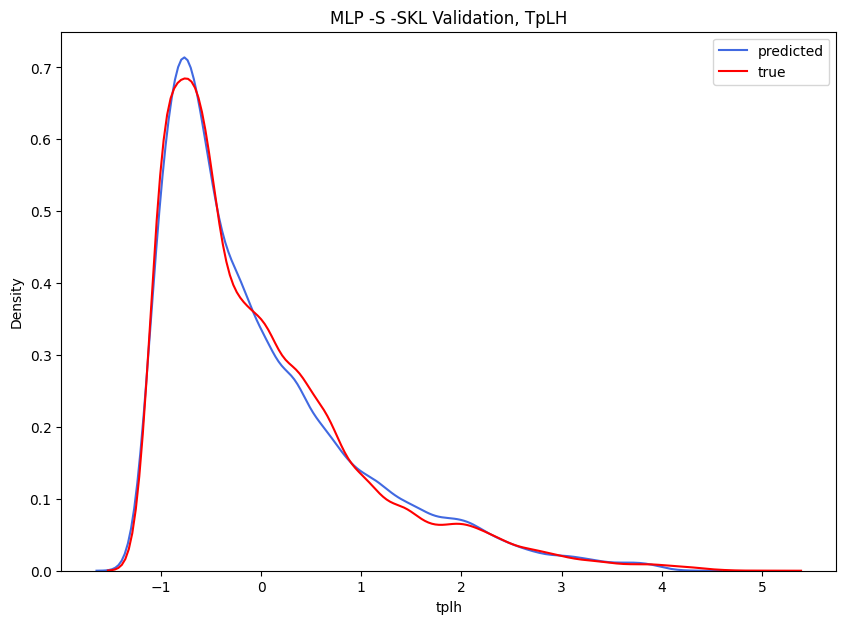

In [28]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpLH')
ax.legend()
plt.show()

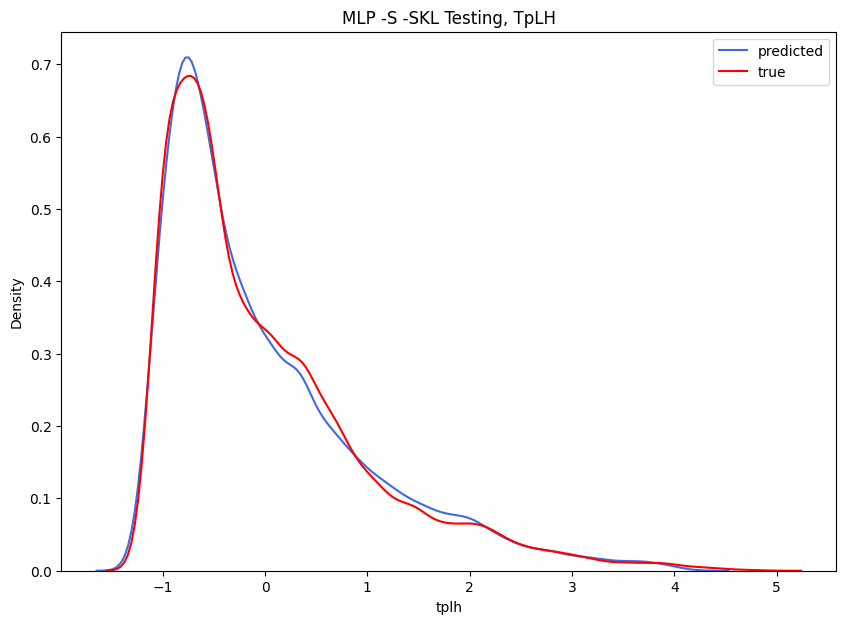

In [29]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpLH')
ax.legend()
plt.show()

#### Predicting Energy

In [30]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['iint'])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [31]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0033891051352725387


In [32]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [33]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['iint'])

0.9930251916830923

In [34]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['iint'], y_pred_sc)
mse = mean_squared_error(y_val_sc['iint'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.08346114724780757
clf: MLP, MSE 0.006965763099920216


In [35]:
score(mlp_regressor, X_val_sc, y_val_sc['iint'], 'mlp_S_SKL', 'corrent', 'val')

{'r2': 0.9930251916830923,
 'rmse': 0.08346114724780757,
 'mse': 0.006965763099920216}

In [36]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [37]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['iint'])

0.9930599012874509

In [38]:
# Testing error
rmse = root_mean_squared_error(yte_sc['iint'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['iint'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.08346682408533163
clf: MLP, MSE 0.006966710722891695


In [39]:
score(mlp_regressor, Xte_sc, yte_sc['iint'], 'mlp_S_SKL', 'corrent', 'test')

{'r2': 0.9930599012874509,
 'rmse': 0.08346682408533163,
 'mse': 0.006966710722891695}

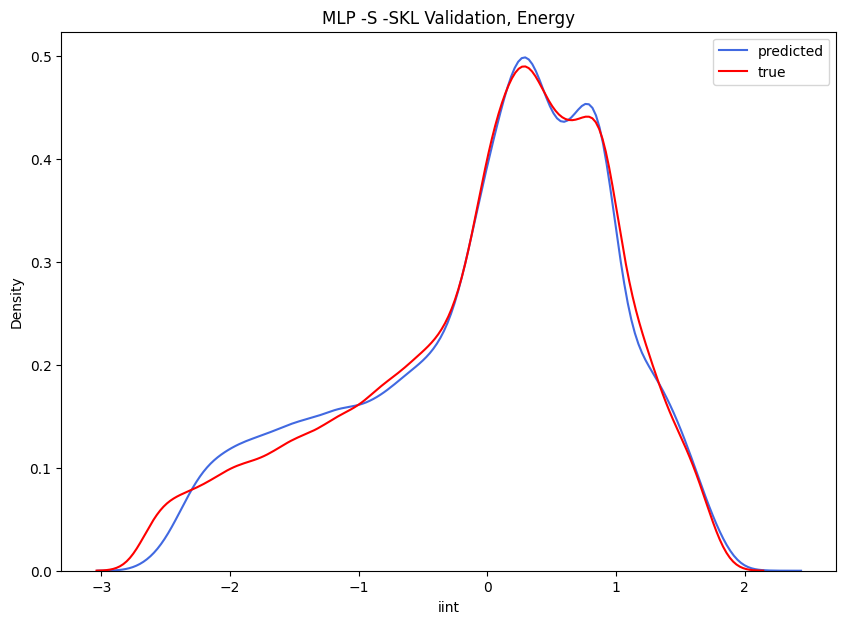

In [40]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['iint'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, Energy')
ax.legend()
plt.show()

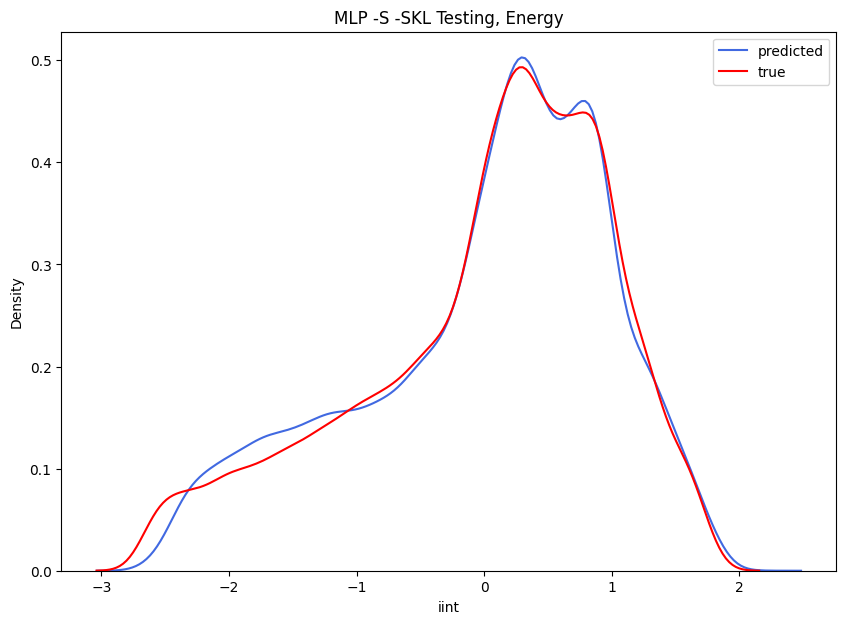

In [41]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['iint'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, Energy')
ax.legend()
plt.show()

### Multi-output model

In [42]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [43]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.002920615323002604


In [44]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [45]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc)

0.9942291732359451

In [46]:
# Validation error
rmse = root_mean_squared_error(y_val_sc, y_pred_sc)
mse = mean_squared_error(y_val_sc, y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.07469253084681317
clf: MLP, MSE 0.005733508383740237


In [47]:
score(mlp_regressor, X_val_sc, y_val_sc, 'mlp_M_SKL', 'all', 'val')

{'r2': 0.9942291732359451,
 'rmse': 0.07469253084681317,
 'mse': 0.005733508383740237}

In [48]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [49]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc)

0.9941828779046343

In [50]:
# Testing error
rmse = root_mean_squared_error(yte_sc, y_test_pred_sc)
mse = mean_squared_error(yte_sc, y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.07552699436095177
clf: MLP, MSE 0.005843612896637739


In [51]:
score(mlp_regressor, Xte_sc, yte_sc, 'mlp_M_SKL', 'all', 'test')

{'r2': 0.9941828779046343,
 'rmse': 0.07552699436095177,
 'mse': 0.005843612896637739}

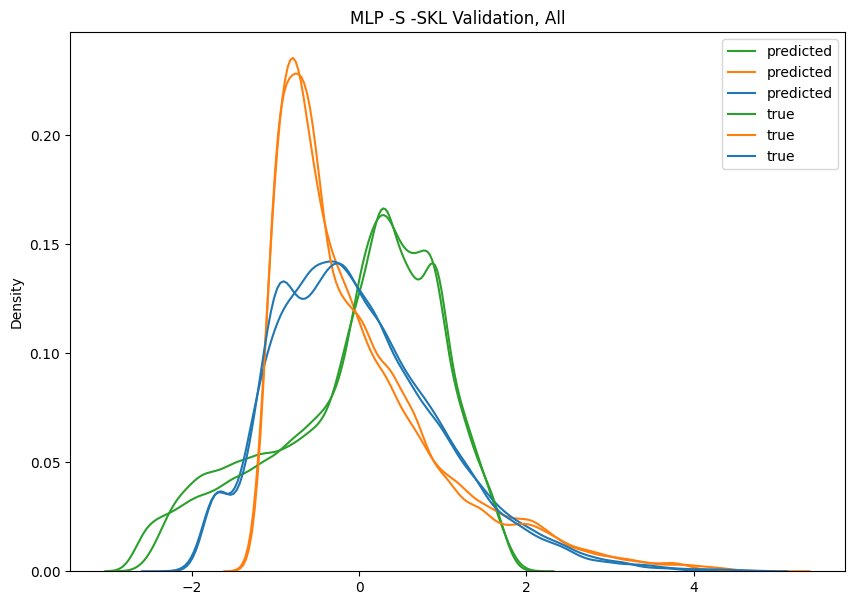

In [52]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc, label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, All')
ax.legend()
plt.show()

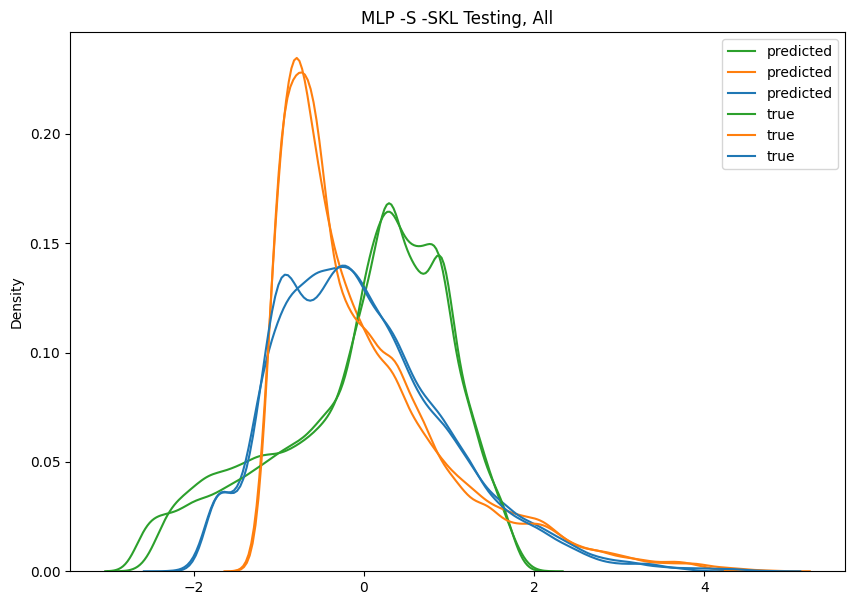

In [53]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc, label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, All')
ax.legend()
plt.show()

## Multi-layer Perceptron for Regression using Keras

Use test set and evaluate()

In [54]:
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1776292963.665524   14569 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776292963.666025   14569 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776292963.699678   14569 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776292965.249961   14569 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### Single-output models

In [55]:
model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train_sc.shape[1:]),
    keras.layers.Dense(1)
])

/home/eduarda/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776292965.523212   14569 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776292965.523562   14678 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776292965.541217   14569 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to

#### Predicting TPHL

In [56]:
model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train_sc, y_train_sc['tphl'], epochs=20, validation_data=(X_val_sc, y_val_sc['tphl']),
                    shuffle=False)

Epoch 1/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1285 - val_loss: 0.0377
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0256 - val_loss: 0.0172
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0122 - val_loss: 0.0091
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0071 - val_loss: 0.0059
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 12/20
2007/2007 ━━━━━━━━

In [57]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['tphl'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['tphl'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step
clf: ANN, rmse: 0.03401083435095293
clf: ANN, mse: 0.0011567368532479597


In [58]:
r2 = r2_score(y_val_sc['tphl'], ypred_sc)
print(f'R²: {r2}')

R²: 0.9988470903771289


In [59]:
score(model, X_val_sc, y_val_sc['tphl'], 'mlp_S_K', 'tphl', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step


{'r2': 0.9988470903771289,
 'rmse': 0.03401083435095293,
 'mse': 0.0011567368532479597}

#### Predicting TPLH

In [60]:
model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train_sc, y_train_sc['tplh'], epochs=20, validation_data=(X_val_sc, y_val_sc['tplh']),
                    shuffle=False)

Epoch 1/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0779 - val_loss: 0.0283
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0184 - val_loss: 0.0117
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0090 - val_loss: 0.0065
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0055 - val_loss: 0.0043
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 12/20
2007/2007 ━━━━━━━━

In [61]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['tplh'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['tplh'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 509us/step
clf: ANN, rmse: 0.030944129257466618
clf: ANN, mse: 0.0009575391355028017


In [62]:
r2 = r2_score(y_val_sc['tplh'], ypred_sc)

print(f'R²: {r2}')

R²: 0.9990168323253212


In [63]:
score(model, X_val_sc, y_val_sc['tplh'], 'mlp_S_K', 'tplh', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 498us/step


{'r2': 0.9990168323253212,
 'rmse': 0.030944129257466618,
 'mse': 0.0009575391355028017}

#### Predicting Energy

In [64]:
model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train_sc, y_train_sc['iint'], epochs=20, validation_data=(X_val_sc, y_val_sc['iint']),
                    shuffle=False)

Epoch 1/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0520 - val_loss: 0.0166
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0078 - val_loss: 0.0071
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0064 - val_loss: 0.0060
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0050 - val_loss: 0.0049
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 839us/step - loss: 0.0038 - val_loss: 0.0038
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 12/20
2007/2007 ━━━━━━

In [65]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['iint'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['iint'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step
clf: ANN, rmse: 0.055321429109484725
clf: ANN, mse: 0.003060460518715744


In [66]:
r2 = r2_score(y_val_sc['iint'], ypred_sc)
print(f'R²: {r2}')

R²: 0.9969355653970273


In [67]:
score(model, X_val_sc, y_val_sc['iint'], 'mlp_S_K', 'corrent', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step


{'r2': 0.9969355653970273,
 'rmse': 0.055321429109484725,
 'mse': 0.003060460518715744}

### Multi-output model

In [68]:
model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train_sc.shape[1:]),
    keras.layers.Dense(3)
])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train_sc, y_train_sc, epochs=20, validation_data=(X_val_sc, y_val_sc), shuffle=False)

Epoch 1/20
  54/2007 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - loss: 1.0247  

/home/eduarda/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.2658 - val_loss: 0.1077
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0834 - val_loss: 0.0657
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0565 - val_loss: 0.0471
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0416 - val_loss: 0.0354
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0318 - val_loss: 0.0274
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0249 - val_loss: 0.0217
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0199 - val_loss: 0.0175
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0162 - val_loss: 0.0144
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0134 - val_loss: 0.0121
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0114 - val_loss: 0.0104
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0100 - val_loss: 0.0092
Epoch 12/20
2007/2007 ━━━━━━━━━━━━━━━━━━━

In [69]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc, ypred_sc)
rmse = root_mean_squared_error(y_val_sc, ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step
clf: ANN, rmse: 0.0690554678440094
clf: ANN, mse: 0.004858240019530058


In [70]:
r2 = r2_score(y_val_sc, ypred_sc)

print(f'R²: {r2}')

R²: 0.9951043725013733


In [71]:
score(model, X_val_sc, y_val_sc, 'mlp_M_K', 'all', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 562us/step


{'r2': 0.9951043725013733,
 'rmse': 0.0690554678440094,
 'mse': 0.004858240019530058}

## Results

In [4]:
import os
import pandas as pd

results = pd.DataFrame.from_dict(scores, orient='index')

path = os.path.join('../outputs/not_32nm_cmos', 'results_mlps')

results.to_csv(path, index_label='target_name')

NameError: name 'scores' is not defined